In [1]:
import pandas as pd 
import geopandas as gpd
import numpy as np
from functions.funcs import *

In [ ]:
def querry_date(data:gpd.GeoDataFrame, date)-> gpd.GeoDataFrame:
    """Returns only dFADs that are active during this time period"""
    data = data.query("MinOfDate <= @date")
    data = data.query("MaxOfDate >= @date")
    return data

ds = gpd.read_parquet(r"Data\Mapped_SAT_MI_Cleanedspeeds.parquet")
target_date = pd.to_datetime("2023-6-12", format="%Y-%m-%d")
ds_active = querry_date(ds, date = target_date) ## All of the active dFADs at this time 
ds_active = ds_active.reset_index()

columns = ["TimeStamp", "x_speed", "y_speed"]
ds_locations = pd.DataFrame()
for label in columns: 
    longlist = Column_to_List(ds_active, label) 
    ds_locations[label] = longlist
lat, lon  = list_of_latlon(ds_active, droplast= False)
ds_locations["lat"] = lat
ds_locations["lon"] =lon
ds_locations.TimeStamp = pd.to_datetime(ds_locations.TimeStamp)

##Filter Timestep by certain threshhold to get locations of FADS within closes  
## UPDATE:This might be better to interp these onto the specific time. 
hourlim = 24
time_threshhold  = pd.Timedelta(hours= hourlim)
time_upper  = target_date
time_lower = target_date - time_threshhold
ds_locations = ds_locations.query(f"TimeStamp > @time_lower")
ds_locations = ds_locations.query(f"TimeStamp < @time_upper")
print(f"Amount of sampled dFAD within {hourlim} hrs : {len(ds_locations)}")
ds_locations = ds_locations.drop_duplicates(subset=["lat"], keep="first")
ds_locations = ds_locations.drop_duplicates(subset=["lon"], keep="first").reset_index(drop = True)

Amount of sampled dFAD within 24 hrs : 130


Notebook to test objective mapping using Bretherton et al 1975.
Steps: 
1) A^-1 matrics

In [ ]:
def C_psi(r, L, sigma2):
    return sigma2 * np.exp( -(r/L)**2)

def R_and_S(r, L, sigma2):
    """r in maginite of vector between messurements, L is length scale in distance, sigma2 is variations in the measurments"""
    F = C_psi(r, L, sigma2)

    R = (2/L**2)*(F)   ##-(1/r)*dFdr      # R(ρ)
    S = (2/L**2 - (4*r**2/L**4))*F   ###-d2Fdr2          # S(ρ)
    return R, S

# Build full observation covariance A (2N x 2N) for stacked [u; v]
def obs_covariance(lons:np.array, lats:np.array, L, sigma2_psi):

    N = len(lons) ##number of measurments 
    A = np.zeros((2*N, 2*N)) #Matrix to hold variences. 

    for i in range(N):
        xi, yi = lons[i], lats[i]
        for j in range(N):
            if i ==j: 
                A[i,j] = (2/L**2)*sigma2_psi
                A[i+N, j+N] = (2/L**2)*sigma2_psi
            else: 
                xj, yj = lons[j], lats[j]

                r= np.abs(haversine_dist(yj,xj, yi, xi))*1000
                delx = (xj - xi)*111000  ## np.abs(haversine_dist(0,xi,0,xj))*1000 # This only produce positives 
                dely = (yj - yi)*111000    ##np.abs(haversine_dist(yi,0,yj,0))*1000 ##this only produces positives
                R_p, S_p = R_and_S(r, L, sigma2_psi)
                
                u1u1 = (delx**2/r**2)*(R_p - S_p)+ S_p
                u1u2 = (delx*dely/r**2)*(R_p - S_p)
                u2u2 = (dely**2/r**2)*(R_p - S_p)+ S_p

                # u1u1 = (dx**2/r**2)*(sigma2_psi*C/L/r + sigma2_psi*C/L*2) - (sigma2_psi*C/L**2) ##Fix there are negetives here
                # u2u2 = (dy**2/r**2)*(sigma2_psi*C/L/r + sigma2_psi*C/L*2) - (sigma2_psi*C/L**2) #and here
                # u1u2 = (dx*dy/r**2)*(sigma2_psi*C/L/r + sigma2_psi*C/L*2) # actually negetives here

                A[i, j] = u1u1
                A[i+N, j] = u1u2
                A[i, j+N] = u1u2
                A[i+N, j+N] = u2u2

    # add observation noise variances on diagonal so inverse is solveable
    # for i in range(2*N):
    #     A[i, i] += sigma_u_obs**2
    return A

def phi_obs(u, v):
    return np.append(u,v)

def C_iu(lat_poi, lon_poi, lats, lons, L, sigma2_psi):
    N = len(lats)
    c_u = np.zeros(N*2)
    c_v = np.zeros(N*2)
    for i in range(N):
        
        ##Recheck this place delx and dely could be sign error 
        r= np.abs(haversine_dist(lat_poi,lon_poi, lats[i], lons[i]))*1000
        delx = (lons[i] - lon_poi)*111000  ## np.abs(haversine_dist(0,xi,0,xj))*1000 # This only produce positives 
        dely = (lats[i] - lat_poi)*111000   ##np.abs(haversine_dist(yi,0,yj,0))*1000 ##this only produces positives
        R_p, S_p = R_and_S(r, L, sigma2_psi)
        u1u1 = (delx**2/r**2)*(R_p - S_p)+ S_p
        u1u2 = (delx*dely/r**2)*(R_p - S_p)

        c_u[i] = u1u1
        c_u[i+N] = u1u2
        c_v[i] = u1u2
        c_v[i+N] = u1u1
        
    return c_u, c_v

def U_xy(lat_poi, lon_poi, lats, lons, L, u,v, sigma2_psi, A_i, phi):
    cs_u, cs_v = C_iu(lat_poi, lon_poi,lats, lons,L ,sigma2_psi )
    N = len(lats)
    b= 0
    c =0 
    for r in range(2*N):
        b += cs_u[r]*(A_i[r,:]*phi).sum()
        c += cs_v[r]*(A_i[r,:]*phi).sum()
    return b,  c

def u_field(xrange, yrange, lats, lons, u,v,L, sigma2_psi):
    L = L*111000
    print(L)
    f_u = np.zeros((len(xrange), len(yrange)))
    f_v = np.zeros((len(xrange), len(yrange)))
    A = obs_covariance(lons, lats, L, sigma2_psi)
    Ai = np.linalg.inv(A)
    phi = phi_obs(u,v)
    print(A)
    print(phi)
    for i in range(len(xrange)):
        print(i)
        for j in range(len(yrange)):
            f_u[i,j] , f_v[i,j] = U_xy(xrange[i], yrange[j], lats, lons, L, u, v,sigma2_psi, Ai, phi)
    return f_u , f_v


In [4]:
data = xr.open_dataset(r"data\cmems.nc")
df = ds_locations #: location data of dFADs for one timestep
u,v = u_field(data.longitude.to_numpy(), data.latitude.to_numpy(), df.lat, df.lon, df.x_speed, df.y_speed, L = 4.5, sigma2_psi =  10e6)
print(u)

499500.0
[[ 8.01602403e-05  8.01600567e-05  8.01566787e-05 ... -1.23950904e-05
  -1.65850735e-05 -1.27990015e-05]
 [ 8.01600567e-05  8.01602403e-05  8.01557087e-05 ... -1.23485118e-05
  -1.65407888e-05 -1.27560809e-05]
 [ 8.01566787e-05  8.01557087e-05  8.01602403e-05 ... -1.25743173e-05
  -1.67565040e-05 -1.30030928e-05]
 ...
 [-1.23950904e-05 -1.23485118e-05 -1.25743173e-05 ...  8.01602403e-05
   7.89970562e-05  7.87017618e-05]
 [-1.65850735e-05 -1.65407888e-05 -1.67565040e-05 ...  7.89970562e-05
   8.01602403e-05  7.96269562e-05]
 [-1.27990015e-05 -1.27560809e-05 -1.30030928e-05 ...  7.87017618e-05
   7.96269562e-05  8.01602403e-05]]
[-0.09979032 -0.05487273 -0.00207067 -0.02779873  0.03603539  0.11737242
  0.1638231   0.03397623  0.02059165  0.02573957  0.04427205  0.06898204
  0.12149075  0.16370364  0.21621236 -0.32872    -0.1816956  -0.17148319
 -0.19165681  0.04115757 -0.00386093 -0.24395961 -0.27953169 -0.26640451
 -0.26872107 -0.11428367 -0.06563589 -0.10424524 -0.27180982 -0

In [5]:
print(u)

[[7.89937229e+00 8.60317249e+00 9.36140869e+00 ... 1.09811265e+02
  1.15099254e+02 1.20503713e+02]
 [6.64854957e+00 7.23991623e+00 7.87691190e+00 ... 9.17227533e+01
  9.61101688e+01 1.00591081e+02]
 [5.59133499e+00 6.08782733e+00 6.62253446e+00 ... 7.65449440e+01
  8.01812061e+01 8.38922666e+01]
 ...
 [5.26713677e-03 5.70040178e-03 6.16319236e-03 ... 4.82685011e-02
  4.95579688e-02 5.07667403e-02]
 [4.29749316e-03 4.65008145e-03 5.02658894e-03 ... 3.87638791e-02
  3.97609993e-02 4.06884431e-02]
 [3.50354202e-03 3.79023518e-03 4.09628760e-03 ... 3.10927433e-02
  3.18604019e-02 3.25681015e-02]]


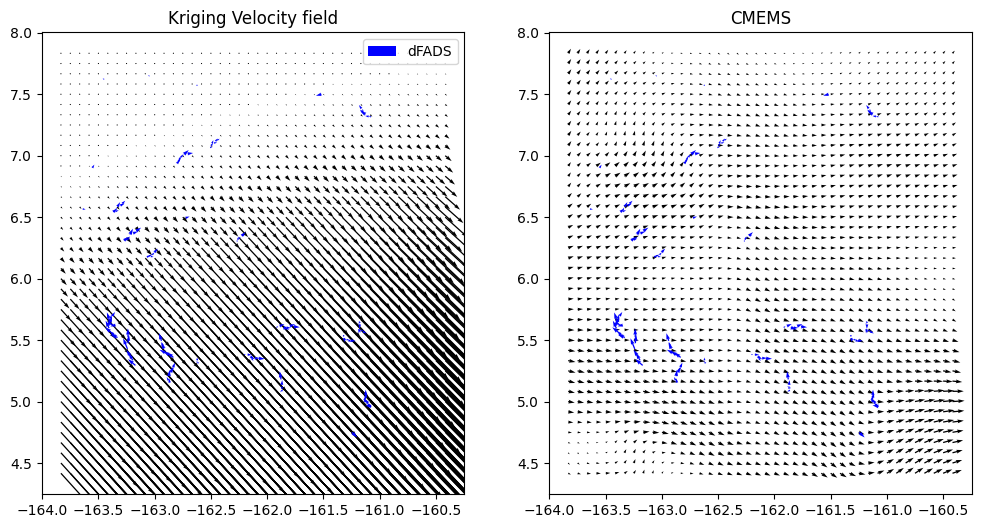

In [6]:
lats = data.latitude
lons = data.longitude
X, Y = np.meshgrid(lons, lats)

fig , ax = plt.subplots(1,2, figsize = (12,6))
scale = 5
slice = data.sel(time= target_date,depth = 15, method= "nearest")

# Plotting Varience underneath 

ax[0].quiver(X,Y, u, v, scale=scale, scale_units='xy', angles='xy', width = 0.003)
ax[0].quiver(ds_locations.lon, ds_locations.lat, ds_locations.x_speed, ds_locations.y_speed, 
             color = "blue", scale=scale, scale_units='xy', angles='xy',width = 0.003, label = "dFADS")

ax[1].quiver(X,Y, slice.uo, slice.vo, scale=scale, scale_units='xy', angles='xy', width = 0.003)
ax[1].quiver(ds_locations.lon, ds_locations.lat, ds_locations.x_speed, ds_locations.y_speed, 
             color = "blue", scale=scale, scale_units='xy', angles='xy',width = 0.003)

##Labels and style
ax[0].set_title("Kriging Velocity field")
ax[1].set_title("CMEMS")
ax[0].legend()
# date = target.Dates.strftime('%Y-%m-%d_%H')
# fig.suptitle(f"{date}, Number of Points: {len(ds_locations)}")
# fig.savefig(fr"..\Figures\Krigging\{date}.png")

In [7]:
### GPT CODE # --- Gaussian streamfunction covariance ---
def C_psi(r, L, sigma2):
    return sigma2 * np.exp(-(r**2) / L**2)

# --- second derivatives of Gaussian covariance Cψ ---
def d2C_dx2(dx, dy, L, sigma2):
    r2 = dx*dx + dy*dy
    C = sigma2*np.exp(-r2 / L**2)
    return C * ((2/L**2) - (4*dx*dx / L**4))

def d2C_dy2(dx, dy, L, sigma2):
    r2 = dx*dx + dy*dy
    C = sigma2*np.exp(-r2 / L**2)
    return C * ((2/L**2) - (4*dy*dy / L**4))

def d2C_dxdy(dx, dy, L, sigma2):
    r2 = dx*dx + dy*dy
    C = sigma2*np.exp(-r2 / L**2)
    return C * ((-4*dx*dy) / L**4)

# ---- Build full observation covariance A (2N x 2N) ----
def obs_covariance(lons, lats, L, sigma_u_obs=0.0002, sigma2_psi=1):

    N = len(lons)
    A = np.zeros((2*N, 2*N))

    for i in range(N):
        xi, yi = lons[i], lats[i]

        for j in range(N):
            xj, yj = lons[j], lats[j]
            dx = xi - xj
            dy = yi - yj

            if i == j:
                # diagonal → variance + observational noise
                A[i, i]         = 1 + sigma_u_obs**2
                A[i+N, i+N]     = 1 + sigma_u_obs**2
                continue

            # Gaussian spatial covariance derivatives
            Cuu = -d2C_dx2(dx, dy, L, sigma2_psi)
            Cvv = -d2C_dy2(dx, dy, L, sigma2_psi)
            Cuv = -d2C_dxdy(dx, dy, L, sigma2_psi)

            # place in matrix
            A[i, j]         = Cuu      # u-u
            A[i+N, j+N]     = Cvv      # v-v
            A[i, j+N]       = Cuv      # u-v
            A[j+N, i]       = Cuv      # v-u (symmetric)

    return A

# --------------------------------------------------------
def phi_obs(u, v):
    return np.append(u, v)

# ---- covariance between prediction location and obs ----
def C_iu(lat_poi, lon_poi, lats, lons, L, sigma2_psi):

    N = len(lats)
    c = np.zeros(2*N)

    for i in range(N):
        dx = lon_poi - lons[i]
        dy = lat_poi - lats[i]

        # second derivatives at this point
        Cuu = -d2C_dx2(dx, dy, L, sigma2_psi)
        Cuv = -d2C_dxdy(dx, dy, L, sigma2_psi)

        c[i]   = Cuu   # u component
        c[i+N] = Cuv   # v component

    return c

# --------------------------------------------------------
def U_xy(lat_poi, lon_poi, lats, lons, L, u, v, sigma2_psi):

    A  = obs_covariance(lons, lats, L, sigma2_psi=sigma2_psi)
    Ai = np.linalg.inv(A)

    phi = phi_obs(u, v)
    cs  = C_iu(lat_poi, lon_poi, lats, lons, L, sigma2_psi)

    return cs @ Ai @ phi   # vector-matrix-vector

# --------------------------------------------------------
def u_field(xrange, yrange, lats, lons, u, v, L, sigma2_psi):

    f = np.zeros((len(xrange), len(yrange)))

    for i in range(len(xrange)):
        print(i)
        for j in range(len(yrange)):
            f[i, j] = U_xy(xrange[i], yrange[j], lats, lons, L, u, v, sigma2_psi)

    return f


In [8]:
###OLD METHODS NOT NEEDED
def C_psi(r, L, sigma2):
    return sigma2 * np.exp( -r/L)

# Build full observation covariance A (2N x 2N) for stacked [u; v]
def obs_covariance(lons:np.array, lats:np.array, L, sigma_u_obs = 0.0002, sigma2_psi =1):

    N = len(lons) ##number of measurments 
    A = np.zeros((2*N, 2*N)) #Matrix to hold variences. 
    lons2 = np.append(lons, lons)
    lats2 = np.append(lats,lats)

    for i in range(N):
        xi, yi = lons2[i], lats2[i]
        for j in range(N):
            xj, yj = lons2[j], lats2[j]
            dx = xi - xj
            dy = yi - yj
            r = np.sqrt(dx*dx + dy*dy)
            C = C_psi(r, L, sigma2_psi)
            u1u1 = (dx**2/r**2)*(sigma2_psi*C/L/r + sigma2_psi*C/L*2) - (sigma2_psi*C/L**2) ##Fix there are negetives here
            u2u2 = (dy**2/r**2)*(sigma2_psi*C/L/r + sigma2_psi*C/L*2) - (sigma2_psi*C/L**2) #and here
            u1u2 = (dx*dy/r**2)*(sigma2_psi*C/L/r + sigma2_psi*C/L*2) # actually negetives here

            A[i, j] = u1u1
            A[i+N, j] = u1u2
            A[i, j+N] = u1u2
            A[i+N, j+N] = u2u2

    # add observation noise variances on diagonal so inverse is solveable
    # for i in range(2*N):
    #     A[i, i] += sigma_u_obs**2
    return A

def phi_obs(u, v):
    return np.append(u,v)

def C_iu(lat_poi, lon_poi, lons, lats, L, sigma2_psi):
    N = len(lats)
    c = np.zeros(N*2)
    for i in range(c/2):
        dx = lon_poi - lons[i]
        dy = lat_poi - lats[i]
        r = np.sqrt(dx**2 +dy**2)
        f = C_psi(r, L, sigma2_psi)
        u1u1 = (dx**2/r**2)*(sigma2_psi*f/L/r + sigma2_psi*f/L*2) - (sigma2_psi*f/L**2) ##Fix there are negetives here
        dx = lon_poi - lons[i+N]
        dy = lat_poi - lats[i+N]
        r = np.sqrt(dx**2 +dy**2)
        f = C_psi(r, L, sigma2_psi)
        u1u2 = (dx*dy/r**2)*(sigma2_psi*f/L/r + sigma2_psi*f/L*2) ##Fix there are negetives here
        c[i] = u1u1
        c[i+N] = u1u2
    return 

def U_xy(lat_poi, lon_poi, lats, lons, L, u,v, sigma_u_obs, sigma2_psi):
    A = obs_covariance(lats, lons, L)
    phi = phi_obs(u,v)
    cs = C_iu(lat_poi, lon_poi,lats, lons,L ,sigma2_psi )
    N = len(lats)
    b= 0
    for r in range(2*N):
        b += cs[r]*A[r,:].sum()
    return b.sum()

        



def P_x(psi_x, psi_y, lats:np.array, lons:np.array, sigma2_psi, L):
    N = len(lats)
    P = np.zeros(N*2)
    lons2 = np.append(lons, lons)
    lats2 = np.append(lats,lats)
    for i in range(2*N):
        xi = lons2[i]
        yi = lats2[i]
        dx = xi - psi_x
        dy = yi - psi_y
        C = C_psi(dx,dy, sigma2_psi, L)
        P[i] = C
    return P 

def psi_xy(psi_x, psi_y, lats, lons, u, v, L, sigma2_psi):
    # Goal is to calc steam fucntion at one location
    A = obs_covariance(lons, lats,L, sigma2_psi=sigma2_psi )
    phi = phi_obs(u,v)
    P = P_x(psi_x, psi_y, lats, lons, sigma2_psi, L)
    N = len(lats)
    psi  = 0
    for r in range(2*N): 
        b= 0
        for s in range(2*N):
            b += A[r,s]*phi[s]
        psi += P[r]*b
    return psi

def psi_field(xrange, yrange, lats, lons, u, v ,L ,sigma2_psi): 
    f = np.zeros((len(xrange)+1, len(yrange)+1))
    
    for i in range(len(xrange)): 
        print(i)
        for j in range(len(yrange)): 
            f[i,j] = psi_xy(xrange[i], yrange[j], lats, lons, u ,v ,L, sigma2_psi)
    return f

def uv_field(psi:np.array): 
    y, x = psi.shape
    u_field = np.zeros((x-1, y-1))
    v_field = np.zeros((x-1, y-1))
    for i in range(y-1): 
        v_field[i,:] = np.diff(psi[i,:])/0.125#need to divide by length scale for derivative
    for i in range(x-1):
        u_field[:,i]= np.diff(psi[:,i])/0.125
    return u_field, v_field    

def psi_field(xrange, yrange, lats, lons, u, v ,L ,sigma2_psi): 
    f = np.zeros((len(xrange)+1, len(yrange)+1))
    
    for i in range(len(xrange)): 
        print(i)
        for j in range(len(yrange)): 
            f[i,j] = psi_xy(xrange[i], yrange[j], lats, lons, u ,v ,L, sigma2_psi)
    return f

def uv_field(psi:np.array): 
    y, x = psi.shape
    u_field = np.zeros((x-1, y-1))
    v_field = np.zeros((x-1, y-1))
    for i in range(y-1): 
        v_field[i,:] = np.diff(psi[i,:])/0.125#need to divide by length scale for derivative
    for i in range(x-1):
        u_field[:,i]= np.diff(psi[:,i])/0.125
    return u_field, v_field    

In [9]:
a = obs_covariance(ds_locations.lon.to_list(), ds_locations.lat.to_list(),L = 0.25)
ainv = np.linalg.inv(a)
longlist = ds_locations.x_speed.to_numpy()
longlist = np.append(longlist, ds_locations.y_speed.to_numpy())


C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_9708\2665721521.py:21: RuntimeWarning: invalid value encountered in scalar divide
  u1u1 = (dx**2/r**2)*(sigma2_psi*C/L/r + sigma2_psi*C/L*2) - (sigma2_psi*C/L**2) ##Fix there are negetives here
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_9708\2665721521.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  u1u1 = (dx**2/r**2)*(sigma2_psi*C/L/r + sigma2_psi*C/L*2) - (sigma2_psi*C/L**2) ##Fix there are negetives here
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_9708\2665721521.py:22: RuntimeWarning: invalid value encountered in scalar divide
  u2u2 = (dy**2/r**2)*(sigma2_psi*C/L/r + sigma2_psi*C/L*2) - (sigma2_psi*C/L**2) #and here
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_9708\2665721521.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  u2u2 = (dy**2/r**2)*(sigma2_psi*C/L/r + sigma2_psi*C/L*2) - (sigma2_psi*C/L**2) #and here
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_9708\2665721521

In [10]:
## Starting with making A 

def Gausian_var(dx,dy, sigma2, L):
    r2 = dx**2 +dy**2
    var = sigma2*np.exp(-0.5*r2/L^2)
    return var 


def A_matrix(u: np.array, v:np.array, lats: np.array, lons:np.array): ## Also need for the diagnals they are going to be zero
    N = len(u) + len(v)
    obs = np.append(u,v)
    lats = np.append(lats, lats)
    lons = np.append(lons, lons)

    A = np.zeros(N, N)

    for i in range(N):
        for j in range(N):
            ##Calcuate varience between the points 
            dx = lons[i] - lons[j]
            dy = lats[i] - lats[j]


            
